In [19]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.nn.conv import GATConv, GCNConv, SplineConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.nn import Sequential
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
import torch.utils.data as torchdata
import tqdm
from math import floor
import gc
import matplotlib.pyplot as plt 
from Model.MENDR.mAtt.optimizer import MixOptimizer
import random
import os
import math
from Datasets.datasetTUAB import WaveletTUABDataset
from torchjd import mtl_backward
from torchjd.aggregation import UPGrad

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [20]:
'''
train_frac = 0.2
val_frac = 0.001
dataset = WaveletDataset(root="/home/hice1/mchen439/scratch/eegfoundationmodeldata", frac=train_frac + val_frac)
num_train = int(len(dataset) * (train_frac / (train_frac + val_frac)))
num_val = len(dataset) - num_train
train_dataset, val_dataset = torchdata.random_split(dataset, [num_train, num_val])
print("Train and Validation Dataset Length: ", len(train_dataset), len(val_dataset))
'''

print("*" * 50)
finetune_train_dataset = WaveletTUABDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/train")
print("Dataset Loaded. Length of Train Dataset: ", len(finetune_train_dataset))
finetune_eval_dataset = WaveletTUABDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/eval")
print("Dataset Loaded. Length of Validation Dataset: ", len(finetune_eval_dataset))


**************************************************
Loading 2130 folders


100%|██████████| 2130/2130 [01:51<00:00, 19.17it/s]


Dataset Loaded. Length of Train Dataset:  269124
Loading 253 folders


100%|██████████| 253/253 [00:12<00:00, 20.46it/s]

Dataset Loaded. Length of Validation Dataset:  30606


In [3]:
### Seed ###
torch.cuda.empty_cache()
random.seed(42)
os.environ['PYTHONHASHSEED'] = str(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)
## CUDNN ##
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True


In [4]:
train_loader = DataLoader(finetune_train_dataset, batch_size=512, num_workers=2, shuffle=True)
val_loader = DataLoader(finetune_eval_dataset, batch_size=512, num_workers=2, shuffle=False)
print(len(train_loader), len(val_loader))

526 60


In [5]:
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']

In [49]:
class WaveletEncoderDecoder(nn.Module):
    def __init__(self, num_channels, sub_patch_size, heads, super_patch_seq_len, encoded_h, device):
        super(WaveletEncoderDecoder, self).__init__()
        self.num_channels = num_channels
        self.channel_dropout = nn.Dropout1d(0.1)
        self.patch_size = sub_patch_size
        self.stride = self.patch_size // 2
        self.device = device
        self.heads = heads
        self.encoded_h = encoded_h
        self.seq_len = super_patch_seq_len

        self.act = nn.GELU()
        L_out = self.seq_len + 2 * (0) - 1 * ((self.patch_size//2) - 1) - 1
        L_out = floor(L_out / (self.stride // 2)) + 1

        self.patch_embedder = nn.Conv1d(in_channels=19, out_channels=19, kernel_size=self.patch_size // 2, stride=self.stride // 2, groups=19).to(self.device)
        self.patch_embedder_lin = nn.Sequential(self.act, nn.Linear(L_out, L_out))

        #self.gnn_channel_encoder = SplineConv(L_out, self.seq_len, dim=1, kernel_size=3).to(self.device)
        self.gnn_channel_encoder = GATConv(L_out, L_out, heads=self.heads, concat=False).to(self.device)
        self.gnn_lin1 = nn.Sequential(self.act, nn.Linear(L_out, L_out))

        self.layer_norm1 = nn.LayerNorm((19, L_out))
        self.layer_norm2 = nn.LayerNorm((19, L_out))

        L_out = L_out + 2 * (0) - 1 * (2 - 1) - 1
        L_out = floor(L_out / 1) + 1
        self.patch_embedder2 = nn.Conv1d(in_channels=19, out_channels=encoded_h, kernel_size=2, stride=1)
        self.layer_norm3 = nn.LayerNorm((encoded_h, L_out))
        self.patch_embedder2_lin = nn.Sequential(self.act, nn.Linear(L_out, L_out))

        # Decoders
        L_out = (L_out - 1) * 1 - 2 * 0 + 1 * (2 - 1) + 0 + 1
        self.up1 = nn.ConvTranspose1d(in_channels=encoded_h, out_channels=encoded_h, kernel_size=2, stride=1, groups=1)
        L_out = (L_out - 1) * 1 - 2 * 0 + 1 * (1 - 1) + 0 + 1
        self.up2 = nn.ConvTranspose1d(in_channels=encoded_h, out_channels=19, kernel_size=1, stride=1, groups=19)
        self.up3 = nn.Sequential(self.act, nn.Linear(L_out, self.seq_len))

    def getEncoderParamCount(self):
        patch_embedder_count = sum(p.numel() for p in self.patch_embedder.parameters() if p.requires_grad)
        gnn_encoder_count = sum(p.numel() for p in self.gnn_channel_encoder.parameters() if p.requires_grad)
        return patch_embedder_count + gnn_encoder_count

    def getDecoderParamCount(self):
        up1_count = sum(p.numel() for p in self.up1.parameters() if p.requires_grad)
        up2_count = sum(p.numel() for p in self.up2.parameters() if p.requires_grad)
        up3_count = sum(p.numel() for p in self.up3.parameters() if p.requires_grad)
        return up1_count + up2_count + up3_count

    def forward(self, graph, x):
        # x: [Batch Size, Channels, Time Steps]
        x = self.channel_dropout(x)
        x = self.patch_embedder(x)
        x = self.patch_embedder_lin(x)
        x = self.layer_norm1(x)
        edge_index = graph.edge_index.to(self.device)
        edge_dist = graph.edge_attr.to(self.device)
        gnn_channel_encoder_input1 = x.view(-1, x.shape[-1])
        channel_encoding = self.gnn_channel_encoder(gnn_channel_encoder_input1, edge_index, edge_dist)
        x = x + channel_encoding.view(x.shape[0], -1, channel_encoding.shape[-1])
        x = self.layer_norm2(x)
        x = self.gnn_lin1(x)
        x = self.patch_embedder2(x)
        x = self.patch_embedder2_lin(x)
        x = self.layer_norm3(x)

        decoding = self.up1(x)
        decoding = self.channel_dropout(decoding)
        decoding = self.up2(decoding)
        decoding = self.up3(decoding)
        return x, decoding

'''
Initialize Encoders for each wavelet band and 
put them into a single object.
'''
class EncoderDecoder(nn.Module):
    def __init__(self, device):
        super(EncoderDecoder, self).__init__()
        self.device = device
        self.encoder_decoders = nn.ParameterDict({
            'delta': WaveletEncoderDecoder(
                    num_channels = 19,
                    sub_patch_size=4,
                    encoded_h=76,
                    heads=1,
                    super_patch_seq_len=41,
                    device = device
                    ),

            'theta': WaveletEncoderDecoder(
                    num_channels = 19,
                    sub_patch_size=4,
                    encoded_h=76,
                    heads=1,
                    super_patch_seq_len=41,
                    device = device
                    ),
            'alpha': WaveletEncoderDecoder(
                    num_channels = 19,
                    sub_patch_size=8,
                    encoded_h=76,
                    heads=1,
                    super_patch_seq_len=81,
                    device = device 
                    ),

            'beta': WaveletEncoderDecoder(
                    num_channels = 19,
                    sub_patch_size=16,
                    encoded_h=152,
                    heads=1,
                    super_patch_seq_len = 161,
                    device = device
                    ),

            'gamma': WaveletEncoderDecoder(
                    num_channels = 19,
                    sub_patch_size = 32,
                    encoded_h = 152,
                    heads=1,
                    super_patch_seq_len=320,
                    device = device
                    ),
        })

    def forward(self, graph, data):
        assert data.keys() == self.encoder_decoders.keys()
        output = {}
        for band, band_decomposition in data.items():
            output[band] = self.encoder_decoders[band](graph, band_decomposition)
        return output

    def freeze_features(self, unfreeze=False, finetuning=False):
        for param in self.parameters():
            param.requires_grad = unfreeze
        if finetuning:
            self.mask_replacement.requires_grad = False

In [50]:
model = EncoderDecoder(device).to(device)
optimizers = {
    'delta': MixOptimizer(torch.optim.Adam(model.encoder_decoders['delta'].parameters(), lr=1e-3)),
    'theta': MixOptimizer(torch.optim.Adam(model.encoder_decoders['theta'].parameters(), lr=1e-3)),
    'alpha': MixOptimizer(torch.optim.Adam(model.encoder_decoders['alpha'].parameters(), lr=1e-3)),
    'beta': MixOptimizer(torch.optim.Adam(model.encoder_decoders['beta'].parameters(), lr=1e-3)),
    'gamma': MixOptimizer(torch.optim.Adam(model.encoder_decoders['gamma'].parameters(), lr=1e-3))
}
for band in BANDS:
    optimizers[band].set_scheduler_t0(len(train_loader))

loss_fn = nn.MSELoss()
#aggregator = UPGrad()
print("Total parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Set Cosine Annealing with Warm Restarts optimizer T_0 to: 526
Set Cosine Annealing with Warm Restarts optimizer T_0 to: 526
Set Cosine Annealing with Warm Restarts optimizer T_0 to: 526
Set Cosine Annealing with Warm Restarts optimizer T_0 to: 526
Set Cosine Annealing with Warm Restarts optimizer T_0 to: 526
Total parameters: 263072


In [51]:
for band in BANDS:
    print(f'{band} Encoder Params: {model.encoder_decoders[band].getEncoderParamCount()}')
    print(f'{band} Decoder Params: {model.encoder_decoders[band].getDecoderParamCount()}')

delta Encoder Params: 1777
delta Decoder Params: 13404
theta Encoder Params: 1777
theta Decoder Params: 13404
alpha Encoder Params: 1733
alpha Decoder Params: 14963
beta Encoder Params: 1809
beta Decoder Params: 52971
gamma Encoder Params: 1961
gamma Decoder Params: 59331


In [52]:
def fft_loss(output, target):
    hanning_window = torch.hann_window(output.shape[-1]).to(device)
    output_windowed = output.clone() * hanning_window.expand_as(output)
    target_windowed = target.clone() * hanning_window.expand_as(target)

    output_fft = torch.fft.fft(output_windowed, dim=-1)
    output_amplitude = torch.abs(output_fft)
    output_angle = torch.angle(output_fft)

    target_fft = torch.fft.fft(target_windowed, dim=-1)
    target_amplitude = torch.abs(target_fft)
    target_angle = torch.abs(target_fft)

    return (loss_fn(output_amplitude, target_amplitude) + (loss_fn(output_angle, target_angle)))

In [53]:
def calculate_band_loss(inputs, outputs, band_model, loss_fn):
    #inputs_compressed = inputs[:, :, 0:band_model.encoded_h] 
    #outputs_compressed = outputs[:, :, 0:band_model.encoded_h] 

    #inputs_masked = inputs[:, :, band_model.encoded_h:] 
    #outputs_masked = outputs[:, :, band_model.encoded_h:] 

    #unmasked_loss = loss_fn(inputs_compressed, outputs_compressed) + fft_loss(inputs_compressed, outputs_compressed)
    #masked_loss = (loss_fn(inputs_masked, outputs_masked) + fft_loss(inputs_masked, outputs_masked))

    loss = loss_fn(inputs, outputs)  # + fft_loss(inputs, outputs) 
    return loss

In [54]:
def train_one_epoch(model, optimizer, loss_fn, train_loader):
	loss_sum = 0
	model.train()

	pbar = tqdm.trange(len(train_loader), desc="Training")
	data_iterator = iter(train_loader)
	for iteration in pbar:
		data = next(data_iterator)
		relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]

		#relevant_bands = [_std_norm(x) for x in relevant_bands]

		batch_size = data['delta'].shape[0]

		inputs = dict(zip(BANDS, relevant_bands))


		outputs = model(data['graph'], inputs)

		losses = dict()
		for band in BANDS:
			loss = calculate_band_loss(inputs[band], outputs[band][1], model.encoder_decoders[band], loss_fn)
			losses[band] = loss
			optimizers[band].zero_grad()
			loss.backward()
			optimizers[band].step()
			loss_sum += loss.item()

		pbar.set_postfix(
			delta_loss=losses['delta'].item(),
			theta_loss=losses['theta'].item(),
			alpha_loss=losses['alpha'].item(),
			beta_loss=losses['beta'].item(),
			gamma_loss=losses['gamma'].item())
	return loss_sum

In [55]:
def validate_one_epoch(model, loss_fn, val_loader):
	loss_sum = 0
	model.eval()

	pbar = tqdm.trange(len(val_loader), desc="Validating")
	data_iterator = iter(val_loader)

	for iteration in pbar:
		data = next(data_iterator)
		relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]

		#relevant_bands = [_std_norm(x) for x in relevant_bands]

		batch_size = data['delta'].shape[0]

		inputs = dict(zip(BANDS, relevant_bands))

		outputs = model(data['graph'], inputs)

		losses = dict()
		for band in BANDS:
			loss = calculate_band_loss(inputs[band], outputs[band][1], model.encoder_decoders[band], loss_fn)
			losses[band] = loss
			loss_sum += loss.item()

		pbar.set_postfix(
			delta_loss=losses['delta'].item(),
			theta_loss=losses['theta'].item(),
			alpha_loss=losses['alpha'].item(),
			beta_loss=losses['beta'].item(),
			gamma_loss=losses['gamma'].item())

	return loss_sum

In [56]:
for epoch_idx in range(3):
	training_loss = train_one_epoch(model, optimizer, loss_fn, train_loader)
	val_loss = validate_one_epoch(model, loss_fn, val_loader)
	#optimizer.scheduler_step(val_loss)
	print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss, "Total Validation Loss: ", val_loss)
	#print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss)

Validating: 100%|██████████| 60/60 [00:19<00:00,  3.14it/s, alpha_loss=31.9, beta_loss=8.79, delta_loss=1.73e+3, gamma_loss=3.16, theta_loss=72]  


Epoch:  0 Total Training Loss:  794077.0262503028 Total Validation Loss:  25141.016073033214


Validating: 100%|██████████| 60/60 [00:19<00:00,  3.14it/s, alpha_loss=28.9, beta_loss=8.75, delta_loss=1.05e+3, gamma_loss=3.16, theta_loss=59.1]


Epoch:  1 Total Training Loss:  672723.3166430593 Total Validation Loss:  18772.145929828286


Validating: 100%|██████████| 60/60 [00:19<00:00,  3.13it/s, alpha_loss=29.1, beta_loss=8.7, delta_loss=1.16e+3, gamma_loss=3.16, theta_loss=54.7]


Epoch:  2 Total Training Loss:  601688.4555741549 Total Validation Loss:  17477.03820888698


In [56]:
torch.save(model.state_dict(), "/home/hice1/mchen439/scratch/models/MENDREncoder3.pt")

In [57]:
model.eval()

for data in val_loader:
    relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]
    
    #relevant_bands = [_std_norm(x) for x in relevant_bands]


    batch_size = data['delta'].shape[0]

    inputs = dict(zip(BANDS, relevant_bands))

    optimizer.zero_grad()

    outputs = model(data['graph'], inputs)
    
    #print(inputs['delta'].shape, outputs['delta'][1].shape)
    #print(inputs['gamma'].shape, outputs['gamma'][1].shape)


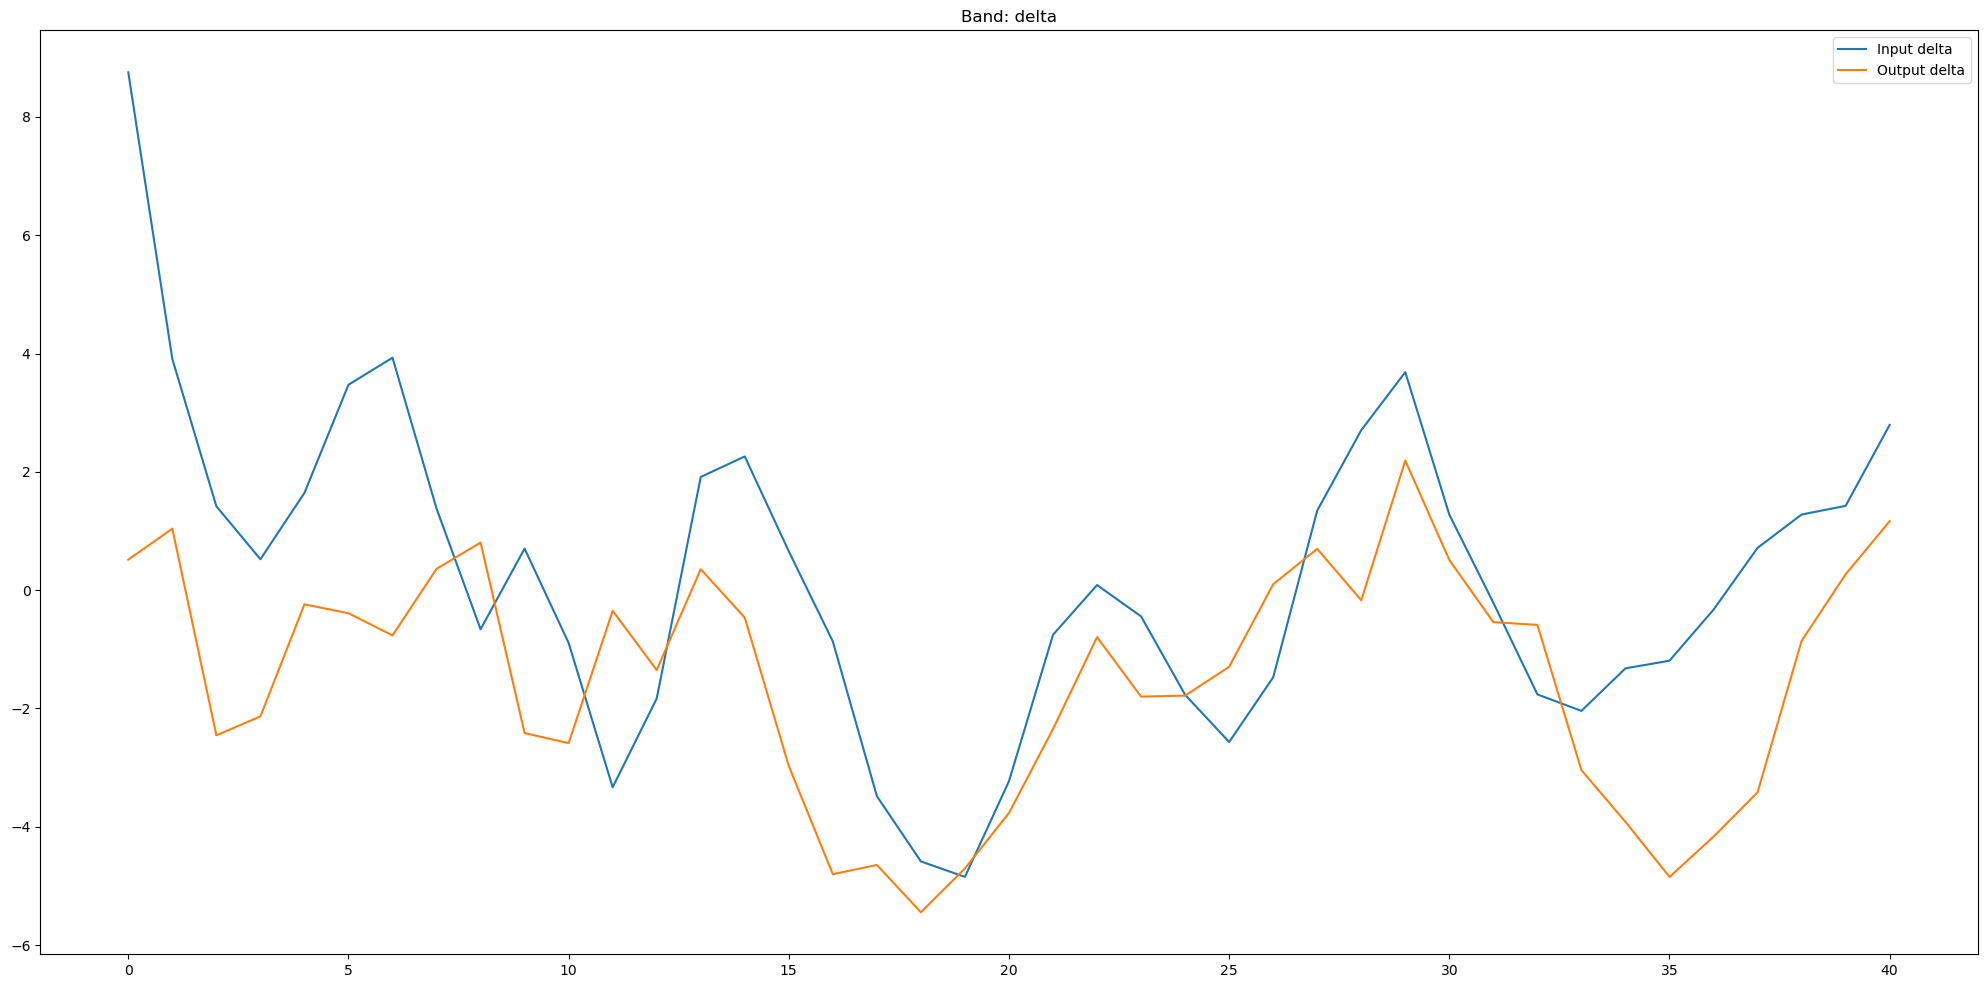

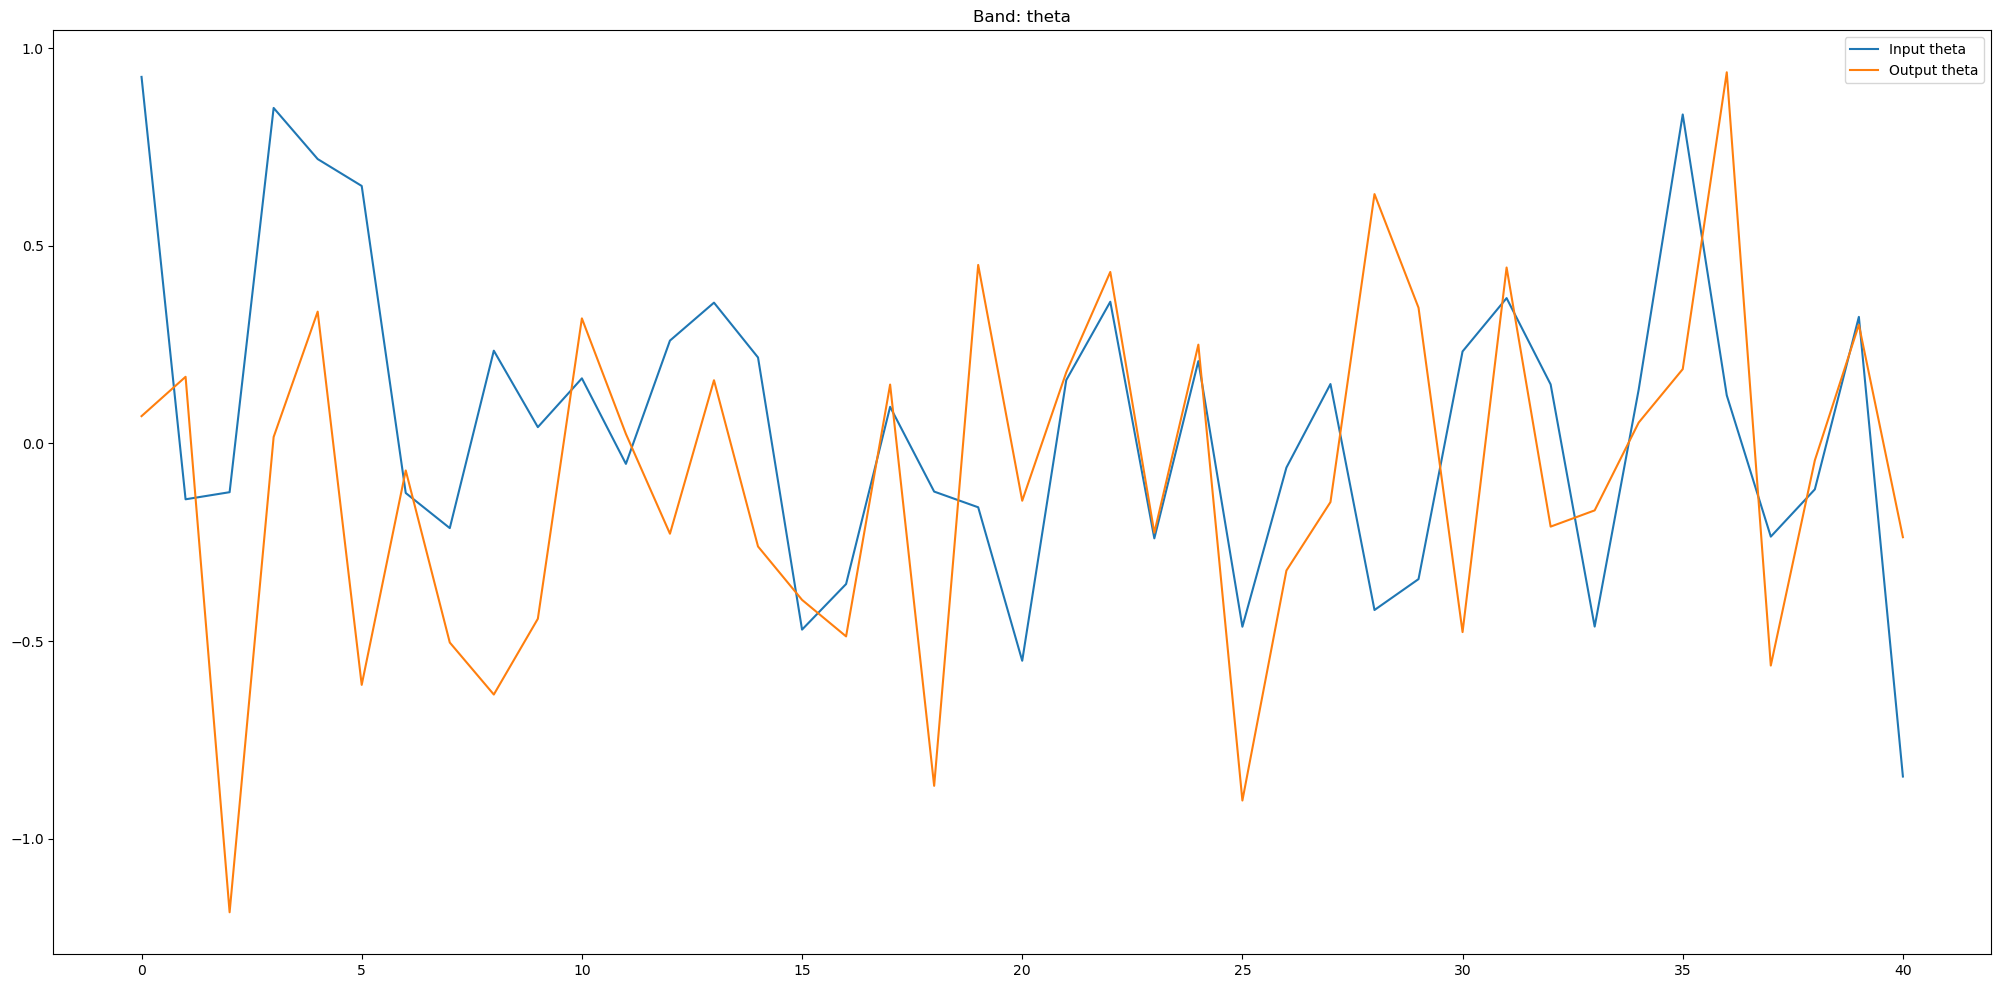

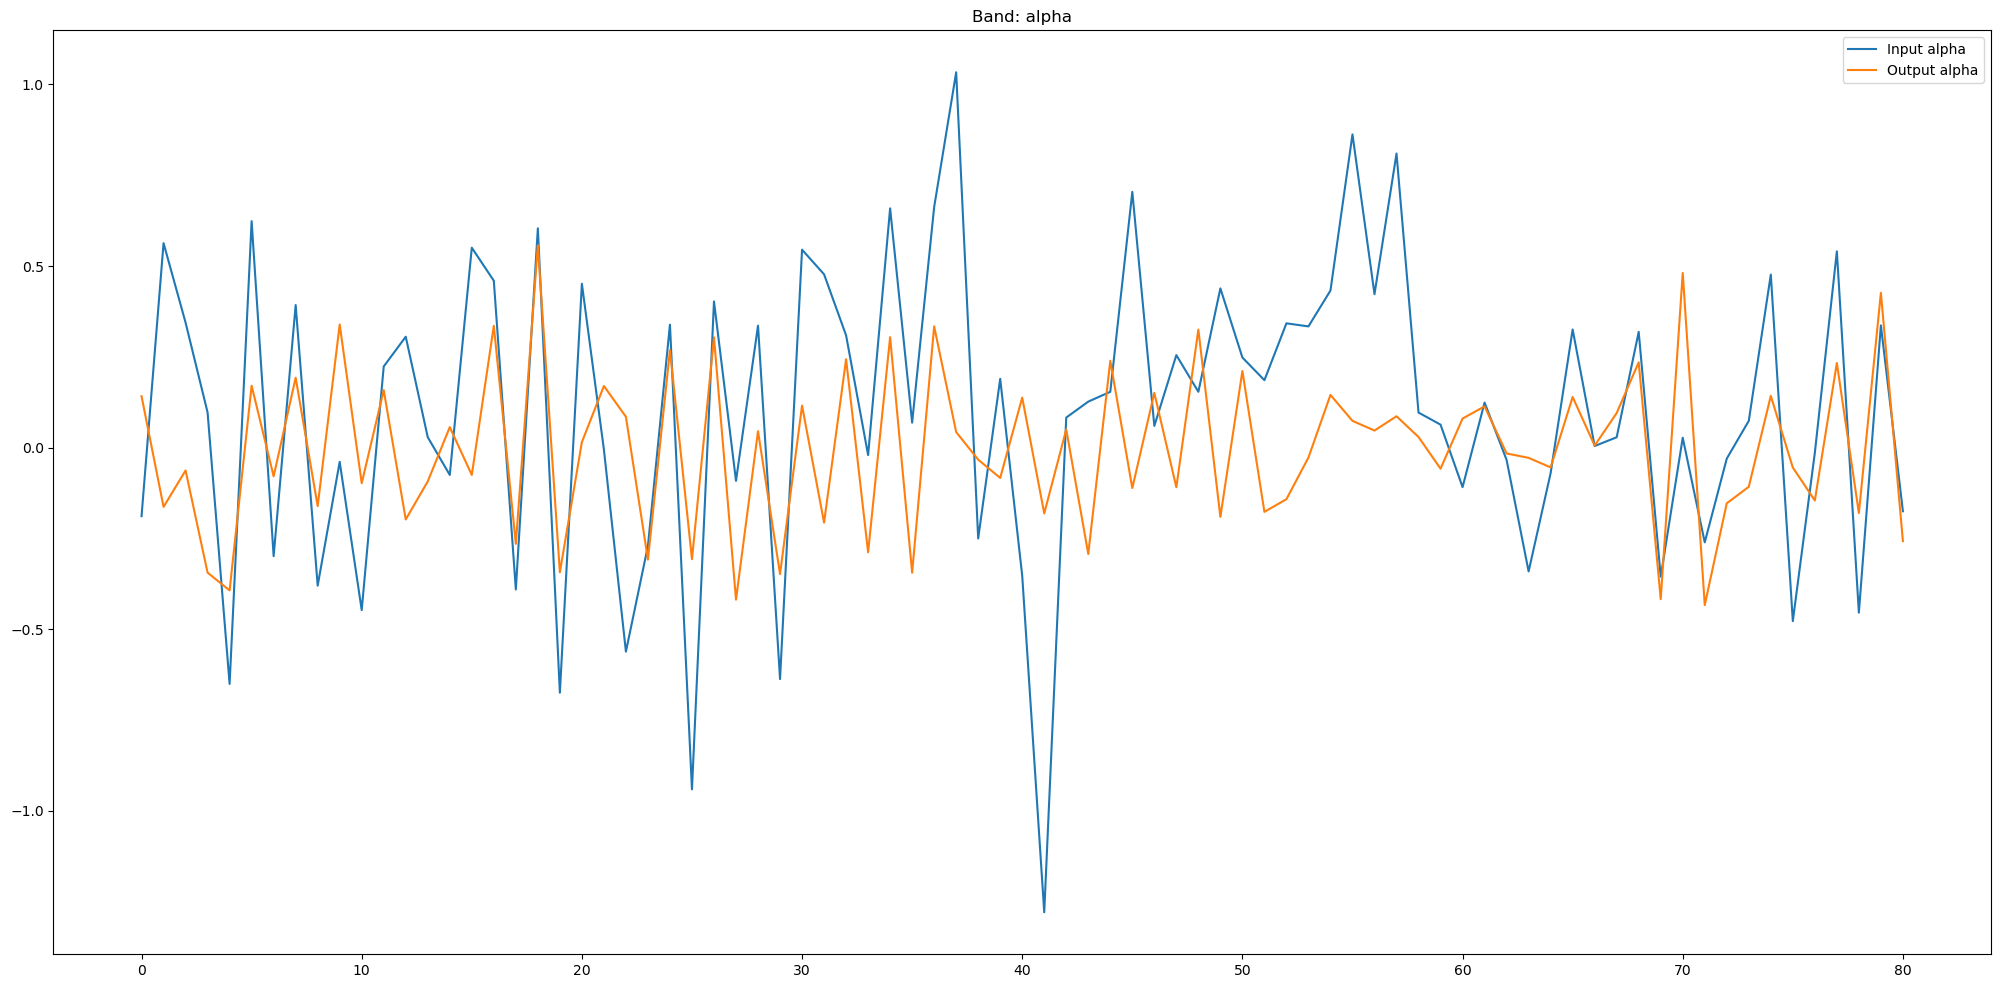

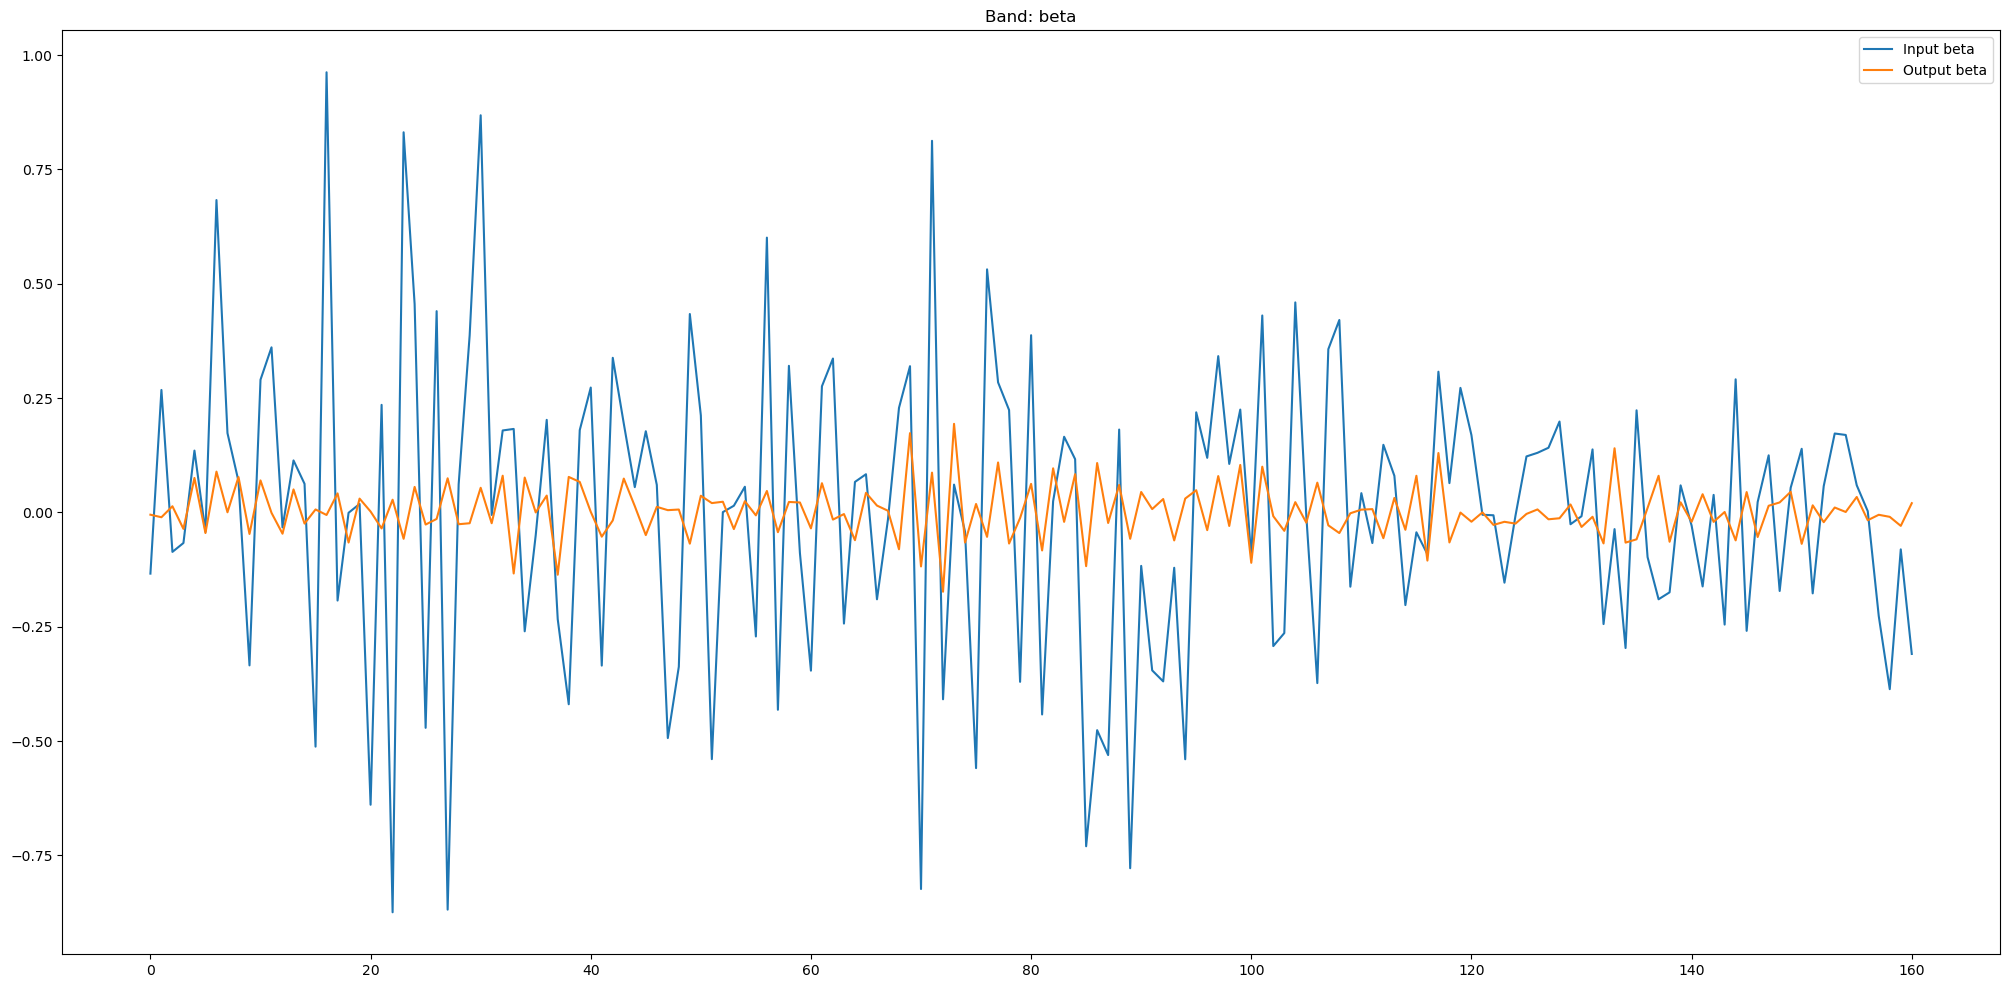

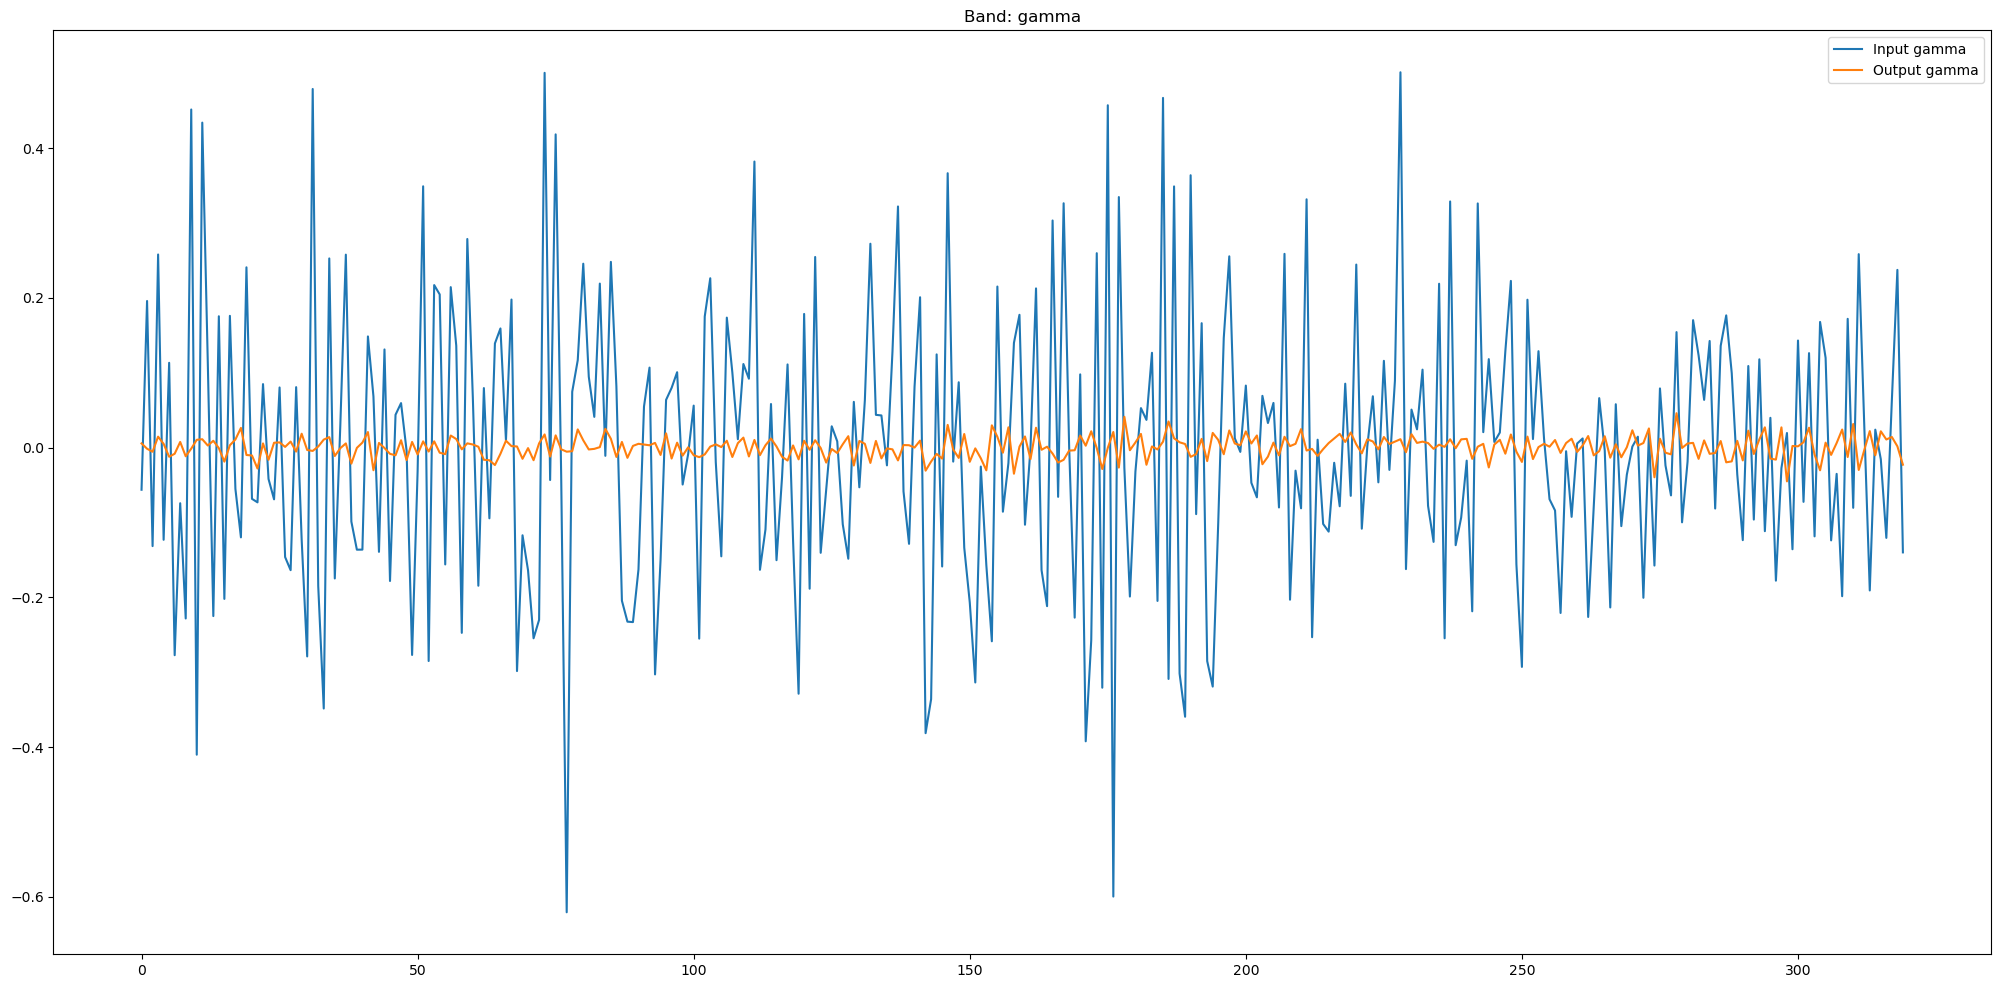

In [58]:
channel = 5
for band in ['delta', 'theta', 'alpha', 'beta', 'gamma']:
    plt.figure(figsize=(25, 12))
    plt.plot(inputs[band][9,channel, :].cpu().detach().numpy(), label=f"Input {band}")
    #plt.plot(outputs[band][0][9, channel, :].cpu().detach().numpy(), label=f"Encoding {band}")
    plt.plot(outputs[band][1][9, channel, :].cpu().detach().numpy(), label=f"Output {band}")
    plt.title(f"Band: {band}")
    plt.legend()
    plt.show()

In [20]:
print("*" * 50)
finetune_train_dataset = WaveletFinetuningDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/train")
print("Dataset Loaded. Length of Train Dataset: ", len(finetune_train_dataset))
finetune_eval_dataset = WaveletFinetuningDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/eval")
print("Dataset Loaded. Length of Validation Dataset: ", len(finetune_eval_dataset))

**************************************************
Loading 2130 folders


100%|██████████| 2130/2130 [01:45<00:00, 20.27it/s]


Dataset Loaded. Length of Train Dataset:  44854
Loading 253 folders


100%|██████████| 253/253 [00:09<00:00, 27.32it/s]


Dataset Loaded. Length of Validation Dataset:  5101


In [34]:
finetune_train_loader = DataLoader(finetune_train_dataset, batch_size=256, num_workers=2, shuffle=True)
finetune_eval_loader = DataLoader(finetune_eval_dataset, batch_size=256, num_workers=2, shuffle=False)
print(len(finetune_train_loader), len(finetune_eval_loader))

176 20


In [36]:
pbar = tqdm.trange(len(finetune_train_loader), desc="Training")
data_iterator = iter(finetune_train_loader)

encoding_outputs = dict()
decoding_outputs = dict()
output_labels = []

for iteration in pbar:
    data = next(data_iterator)
    
    relevant_bands = [data['delta'].float().to(device),
                        data['theta'].float().to(device),
                        data['alpha'].float().to(device),
                        data['beta'].float().to(device),
                        data['gamma'].float().to(device)]

    relevant_bands = [_std_norm(x) for x in relevant_bands]

    inputs = dict(zip(BANDS, relevant_bands))

    with torch.no_grad():
        encoder_outputs = model(data['graph'], inputs)
        output_labels.append(data['graph'].y)
        for band, (encodings, decodings) in encoder_outputs.items():
            if band not in encoding_outputs:
                encoding_outputs[band] = []
            if band not in decoding_outputs:
                decoding_outputs[band] = []
            
            encoding_outputs[band].append(encodings)
            decoding_outputs[band].append(decodings)

Training: 100%|██████████| 176/176 [02:18<00:00,  1.27it/s]


In [37]:
encoding_output_train_all = dict()
for band, encodings in encoding_outputs.items():
    encoding_output_train_all[band] = torch.cat(encodings, dim=0).cpu().numpy()
    print(band, encoding_output_train_all[band].shape)

output_labels_train_all = torch.cat(output_labels, dim=0).cpu().numpy()

delta (44854, 209, 16)
theta (44854, 209, 16)
alpha (44854, 209, 32)
beta (44854, 209, 64)
gamma (44854, 209, 128)


In [39]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.decomposition import PCA

/usr/local/pace-apps/manual/packages/anaconda3/2023.03/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [43]:
reducer2 = umap.UMAP(n_components=2)

  0%|          | 0/5 [00:00<?, ?it/s]

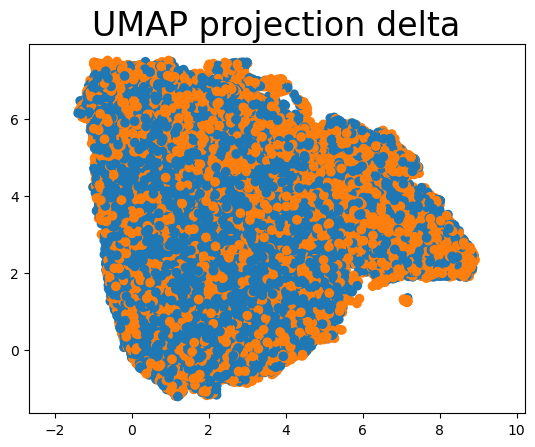

 20%|██        | 1/5 [00:15<01:00, 15.12s/it]

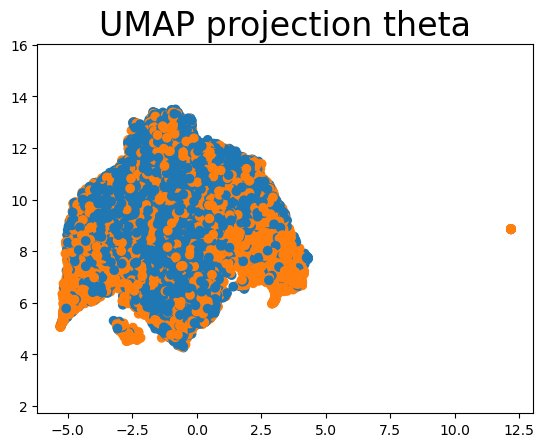

 40%|████      | 2/5 [00:30<00:45, 15.29s/it]

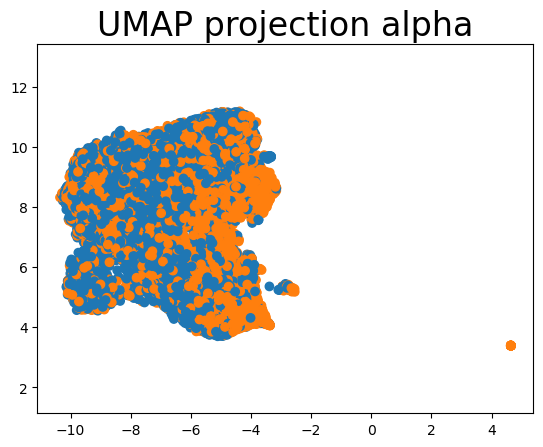

 60%|██████    | 3/5 [01:02<00:45, 22.69s/it]

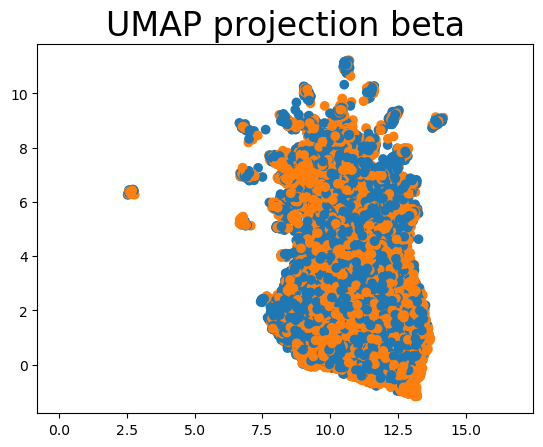

 80%|████████  | 4/5 [01:57<00:35, 35.73s/it]

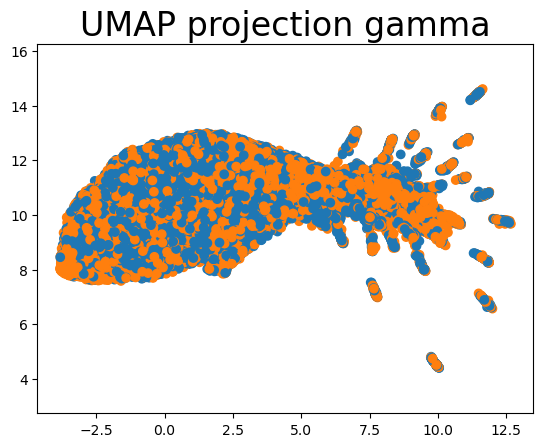

100%|██████████| 5/5 [03:38<00:00, 43.67s/it]


In [55]:
for band in tqdm.tqdm(['delta', 'theta', 'alpha', 'beta', 'gamma']):
    data = encoding_output_train_all[band].reshape(encoding_output_train_all[band].shape[0], -1)
    embeddings = reducer2.fit_transform(data, jobs=-1)
    fig = plt.figure()
    ax = fig.add_subplot()
    ax.scatter(
        embeddings[:, 0],
        embeddings[:, 1],
        c=[sns.color_palette()[x] for x in output_labels_train_all])

    plt.gca().set_aspect('equal', 'datalim')
    plt.title(f'UMAP projection {band}', fontsize=24)
    plt.show()